In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install emoji
import os, re, random, time, math, html, unicodedata, shutil
from collections import Counter
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import emoji

zip_path, DATA = '/content/drive/MyDrive/transformer-main (2).zip', '/content/extracted_data'
if os.path.exists(zip_path):
    !unzip -o -q "{zip_path}" -d {DATA}
    DATA = next((root for root, _, files in os.walk(DATA) if 'train.csv' in files), DATA)
else: DATA = os.path.join(os.getcwd(), "data", "splits")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 4))

PROJECT = os.getcwd()
PAD_ID, UNK_ID, CLS_ID = 0, 1, 2
MAX_VOCAB, MAX_SEQLEN, NUM_CLASSES = 30_000, 64, 3
BATCH, EPOCHS, PATIENCE = 64, 10, 4
HIDDEN, NUM_HEADS, NUM_LAYERS, FF_DIM = 128, 4, 3, 256
DROPOUT, PEAK_LR, MIN_LR, LABEL_SMOOTH = 0.15, 5e-4, 1e-6, 0.1
USE_FOCAL, FOCAL_GAMMA, USE_OVERSAMPLING = True, 2.0, True

print(f"DATA_PATH: {DATA} | HIDDEN={HIDDEN} HEADS={NUM_HEADS} LAYERS={NUM_LAYERS}")

DATA_PATH: /content/extracted_data/transformer-main/data/splits | HIDDEN=128 HEADS=4 LAYERS=3


In [ ]:
URL_RE, MENTION_RE, HASHTAG_RE = re.compile(r"(https?://\S+|www\.\S+)", re.I), re.compile(r"(?<!\w)@[A-Za-z0-9_]+"), re.compile(r"#([A-Za-z0-9_]+)")

def normalize_tweet(text):
    if pd.isna(text): return ""
    text = unicodedata.normalize("NFKC", html.unescape(str(text)))
    text = URL_RE.sub(" <url> ", text)
    text = MENTION_RE.sub(" <user> ", text)
    text = HASHTAG_RE.sub(lambda m: f" <hashtag> {m.group(1).replace('_', ' ')} ", text)
    text = emoji.demojize(text, delimiters=(" emoji_", " "))
    text = re.sub(r"emoji_([A-Za-z0-9_+\-]+)", lambda m: "emoji_" + m.group(1).replace("-", "_"), text)
    text = re.sub(r"!{2,}", " <exclaim> ", text); text = re.sub(r"\?{2,}", " <question> ", text); text = re.sub(r"\.{3,}", " <ellipsis> ", text)
    text = re.sub(r"[^\w\s'<>\-]", " ", text, flags=re.UNICODE).replace("-", " ").lower()
    return re.sub(r"\s+", " ", text).strip()

tr_df = pd.read_csv(os.path.join(DATA, "train.csv")).dropna(subset=["text", "label"])
va_df = pd.read_csv(os.path.join(DATA, "validation.csv")).dropna(subset=["text", "label"])
te_df = pd.read_csv(os.path.join(DATA, "test.csv")).dropna(subset=["text", "label"])

tr_norm, va_norm, te_norm = [normalize_tweet(t) for t in tr_df["text"]], [normalize_tweet(t) for t in va_df["text"]], [normalize_tweet(t) for t in te_df["text"]]

# Mục mới

In [ ]:
word_counts = Counter(w for text in tr_norm for w in text.split())
vocab = {"[PAD]": PAD_ID, "[UNK]": UNK_ID, "[CLS]": CLS_ID}
vocab.update({w: i + 3 for i, (w, _) in enumerate(word_counts.most_common(MAX_VOCAB - 3))})
V = len(vocab)

def encode(texts):
    ids, mask = np.full((len(texts), MAX_SEQLEN), PAD_ID, dtype=np.int64), np.zeros((len(texts), MAX_SEQLEN), dtype=np.float32)
    for i, t in enumerate(texts):
        toks = t.split()[:MAX_SEQLEN - 1]
        ids[i, 0], mask[i, 0] = CLS_ID, 1.0
        for j, w in enumerate(toks):
            ids[i, j + 1], mask[i, j + 1] = vocab.get(w, UNK_ID), 1.0
    return ids, mask

Xtr, Mtr, Ytr = *encode(tr_norm), tr_df["label"].astype(int).values
Xv, Mv, Yv = *encode(va_norm), va_df["label"].astype(int).values
Xte, Mte, Yte = *encode(te_norm), te_df["label"].astype(int).values

class_counts = np.bincount(Ytr)
class_weights = torch.tensor(len(Ytr) / (NUM_CLASSES * class_counts), dtype=torch.float)
print(f"Vocab={V} | Train={len(Ytr)} Val={len(Yv)} Test={len(Yte)}")

class DS(Dataset):
    def __init__(self, ids, mask, labels):
        self.ids, self.mask, self.labels = torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.float), torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.ids[i], self.mask[i], self.labels[i]

train_ds, val_ds, test_ds = DS(Xtr, Mtr, Ytr), DS(Xv, Mv, Yv), DS(Xte, Mte, Yte)
sampler = WeightedRandomSampler([class_weights[l].item() for l in Ytr], num_samples=len(Ytr), replacement=True) if USE_OVERSAMPLING else None
train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, shuffle=(sampler is None), pin_memory=True)
val_loader, test_loader = DataLoader(val_ds, batch_size=BATCH*2, pin_memory=True), DataLoader(test_ds, batch_size=BATCH*2, pin_memory=True)

Vocab=30000 | Train=38914 Val=8980 Test=11975


In [ ]:
class MultiScaleConv(nn.Module):
    def __init__(self, h, drop=0.1):
        super().__init__()
        c = h // 4
        self.convs = nn.ModuleList([nn.Conv1d(h, c, k, padding=k//2) for k in [2,3,4,5]])
        self.bn, self.drop = nn.BatchNorm1d(h), nn.Dropout(drop)
    def forward(self, x):
        t, L = x.transpose(1, 2), x.size(1)
        return self.drop(F.gelu(self.bn(torch.cat([c(t)[:,:,:L] for c in self.convs], 1))).transpose(1, 2))

class MHAttn(nn.Module):
    def __init__(self, h, heads, drop=0.1):
        super().__init__()
        self.heads, self.d = heads, h // heads
        self.qkv, self.proj = nn.Linear(h, h*3), nn.Linear(h, h)
        self.drop, self.scale = nn.Dropout(drop), (h // heads) ** -0.5
    def forward(self, x, mask=None):
        B, L, D = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.heads, self.d).permute(2, 0, 3, 1, 4)
        a = (qkv[0] @ qkv[1].transpose(-2, -1)) * self.scale
        if mask is not None: a = a.masked_fill(mask.unsqueeze(1).unsqueeze(2) == 0, float("-inf"))
        return self.proj((self.drop(F.softmax(a, dim=-1)) @ qkv[2]).transpose(1, 2).reshape(B, L, D))

class Block(nn.Module):
    def __init__(self, h, heads, ff, drop=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(h), nn.LayerNorm(h)
        self.attn, self.conv = MHAttn(h, heads, drop), MultiScaleConv(h, drop)
        self.ff = nn.Sequential(nn.Linear(h, ff), nn.GELU(), nn.Dropout(drop), nn.Linear(ff, h), nn.Dropout(drop))
    def forward(self, x, mask=None):
        n = self.ln1(x)
        return x + self.attn(n, mask) + self.conv(n) + self.ff(self.ln2(x))

class AttnPool(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(h, h//2), nn.Tanh(), nn.Linear(h//2, 1, bias=False))
    def forward(self, x, mask):
        s = self.net(x).squeeze(-1).masked_fill(mask == 0, float("-inf"))
        return (x * F.softmax(s, dim=-1).unsqueeze(-1)).sum(1)

class ElectraHybrid(nn.Module):
    def __init__(self, V, h, heads, layers, ff, n_cls, max_len, drop=0.2):
        super().__init__()
        self.tok_emb, self.pos_emb = nn.Embedding(V, h, padding_idx=PAD_ID), nn.Embedding(max_len, h)
        self.ln, self.drop = nn.LayerNorm(h), nn.Dropout(drop)
        self.layers = nn.ModuleList([Block(h, heads, ff, drop) for _ in range(layers)])
        self.pool = AttnPool(h)
        self.classifier = nn.Sequential(nn.Linear(h*3, h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(drop), nn.Linear(h, n_cls))
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, std=0.02)
            elif isinstance(m, nn.Conv1d): nn.init.kaiming_normal_(m.weight)
    def forward(self, ids, mask):
        pos = torch.arange(ids.size(1), device=ids.device).unsqueeze(0)
        x = self.drop(self.ln(self.tok_emb(ids) + self.pos_emb(pos)))
        for layer in self.layers: x = layer(x, mask)
        cls, att = x[:, 0], self.pool(x, mask)
        mx = x.masked_fill(mask.unsqueeze(-1) == 0, float("-inf")).max(1)[0]
        return self.classifier(torch.cat([cls, att, mx], -1))

print("Model Architecture Loaded OK")

Model Architecture Loaded OK


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda": torch.set_float32_matmul_precision("high")

model = ElectraHybrid(V, HIDDEN, NUM_HEADS, NUM_LAYERS, FF_DIM, NUM_CLASSES, MAX_SEQLEN, DROPOUT).to(device)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        return (((1 - torch.exp(-ce)) ** self.gamma) * ce).mean()

optimizer = torch.optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=0.01)
criterion = FocalLoss(alpha=class_weights.to(device), gamma=FOCAL_GAMMA) if USE_FOCAL else nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=LABEL_SMOOTH)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

total_steps, warmup_steps = len(train_loader) * EPOCHS, int(len(train_loader) * EPOCHS * 0.1)

def get_lr(step):
    if step < warmup_steps: return PEAK_LR * step / max(1, warmup_steps)
    p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return MIN_LR + 0.5 * (PEAK_LR - MIN_LR) * (1 + math.cos(math.pi * p))

print(f"Device={device} | Params={sum(p.numel() for p in model.parameters()):,} | Loss={'FocalLoss' if USE_FOCAL else 'CrossEntropy'}")

Device=cpu | Params=4,477,315 | Loss=FocalLoss


In [ ]:
writer = SummaryWriter(log_dir="runs/electra_hybrid")
best_acc, best_ep, no_imp, gs, t0 = 0, 0, 0, 0, time.time()
hist = {"tl": [], "vl": [], "va": []}

for ep in range(EPOCHS):
    et = time.time()
    model.train(); tl = 0
    for ids, mask, lbl in train_loader:
        ids, mask, lbl = ids.to(device, non_blocking=True), mask.to(device, non_blocking=True), lbl.to(device, non_blocking=True)
        for g in optimizer.param_groups: g["lr"] = get_lr(gs)
        gs += 1
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            loss = criterion(model(ids, mask), lbl)
        if not torch.isnan(loss):
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); tl += loss.item()
    tl /= len(train_loader)

    model.eval(); p, t, vl = [], [], 0
    with torch.no_grad():
        for ids, mask, lbl in val_loader:
            ids, mask, lbl = ids.to(device, non_blocking=True), mask.to(device, non_blocking=True), lbl.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                o = model(ids, mask); vl += criterion(o, lbl).item()
            p.extend(o.argmax(-1).cpu().numpy()); t.extend(lbl.cpu().numpy())
    vl /= len(val_loader); va = accuracy_score(t, p)
    hist["tl"].append(tl); hist["vl"].append(vl); hist["va"].append(va)
    for k, v in [("Loss/train", tl), ("Loss/val", vl), ("Accuracy/val", va), ("LR", get_lr(gs))]: writer.add_scalar(k, v, ep+1)
    print(f"Ep {ep+1:02d}/{EPOCHS} | {time.time()-et:.0f}s | tl={tl:.4f} vl={vl:.4f} va={va:.4f}")

    if va > best_acc:
        best_acc, best_ep, no_imp = va, ep+1, 0
        os.makedirs(os.path.join(PROJECT, "checkpoints"), exist_ok=True)
        torch.save(model.state_dict(), os.path.join(PROJECT, "checkpoints", "electra_best.pt"))
    elif (no_imp := no_imp + 1) >= PATIENCE:
        print(f"Early stop at ep {ep+1}"); break

writer.close()
print(f"Done in {((time.time()-t0)/60):.1f}min | Best Val Acc={best_acc:.4f} at ep {best_ep}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep 01/10 | 370s | tl=0.6804 vl=0.4488 va=0.4559


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep 02/10 | 365s | tl=0.2843 vl=0.3817 va=0.5798


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Ep 08/10 | 358s | tl=0.0293 vl=1.0801 va=0.6164


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep 09/10 | 354s | tl=0.0246 vl=0.9811 va=0.6195


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep 10/10 | 361s | tl=0.0238 vl=0.9201 va=0.6117
Early stop at ep 10
Done in 61.3min | Best Val Acc=0.6276 at ep 6


In [ ]:
model.load_state_dict(torch.load(os.path.join(PROJECT, "checkpoints", "electra_best.pt"), weights_only=True))
model.eval(); p, t = [], []
with torch.no_grad():
    for ids, mask, lbl in test_loader:
        ids, mask, lbl = ids.to(device, non_blocking=True), mask.to(device, non_blocking=True), lbl.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            o = model(ids, mask)
        p.extend(o.argmax(-1).cpu().numpy()); t.extend(lbl.cpu().numpy())

acc = accuracy_score(t, p)
report = classification_report(t, p, target_names=["Neg","Neu","Pos"], output_dict=True)
cm = confusion_matrix(t, p)

w = SummaryWriter(log_dir="runs/electra_hybrid")
w.add_scalar("Test/accuracy", acc)
labels = ["Neg", "Neu", "Pos"]
w.add_text("Confusion Matrix", "| Actual | Predicted | Count |\n|---|---|---|\n" + "\n".join(f"| {labels[i]} | {labels[j]} | {int(cm[i][j])} |" for i in range(3) for j in range(3)))
w.add_text("Per-Class Metrics", "| Class | Precision | Recall | F1-Score | Support |\n|---|---|---|---|---|\n" + "\n".join(f"| {c} | {report[c]['precision']:.4f} | {report[c]['recall']:.4f} | {report[c]['f1-score']:.4f} | {report[c]['support']} |" for c in labels))
w.close()

print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)\n" + classification_report(t, p, target_names=["Neg","Neu","Pos"], digits=4))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test Accuracy: 0.6304 (63.04%)
              precision    recall  f1-score   support

         Neg     0.5594    0.5400    0.5495      2276
         Neu     0.6511    0.6287    0.6397      5492
         Pos     0.6407    0.6815    0.6604      4207

    accuracy                         0.6304     11975
   macro avg     0.6171    0.6167    0.6166     11975
weighted avg     0.6300    0.6304    0.6299     11975



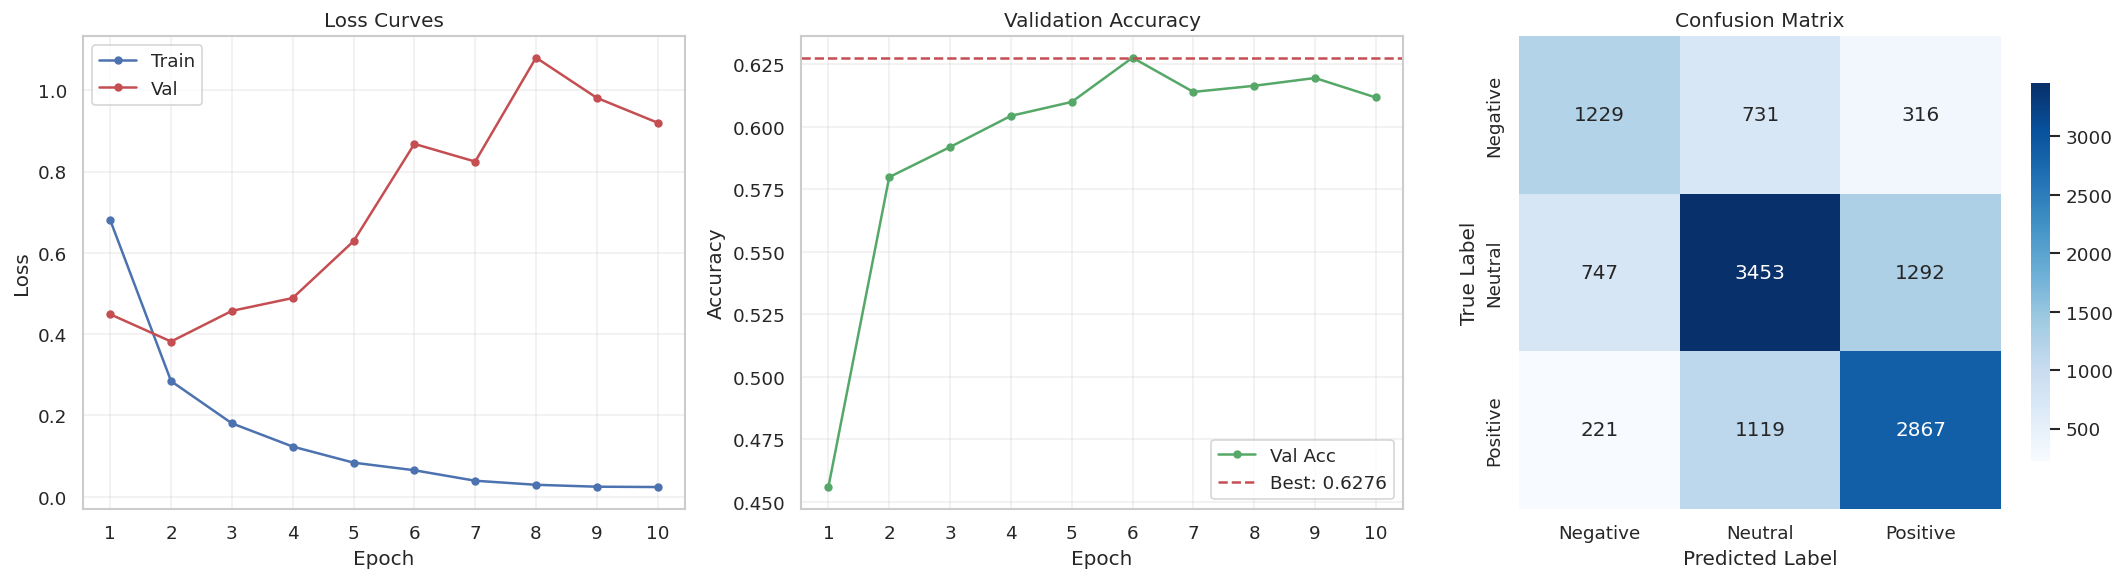

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo khung 1 hàng 3 cột duy nhất
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
ep = list(range(1, len(hist["tl"]) + 1))
labels = ["Negative", "Neutral", "Positive"]

# 1. Loss Curves
a1.plot(ep, hist["tl"], 'b-o', label='Train', ms=4); a1.plot(ep, hist["vl"], 'r-o', label='Val', ms=4)
a1.set(title='Loss Curves', xlabel='Epoch', ylabel='Loss', xticks=ep); a1.legend(); a1.grid(True, alpha=0.3)

# 2. Validation Accuracy
a2.plot(ep, hist["va"], 'g-o', label='Val Acc', ms=4); a2.axhline(best_acc, color='r', ls='--', label=f'Best: {best_acc:.4f}')
a2.set(title='Validation Accuracy', xlabel='Epoch', ylabel='Accuracy', xticks=ep); a2.legend(loc='lower right'); a2.grid(True, alpha=0.3)

# 3. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar_kws={"shrink": 0.8}, ax=a3)
a3.set(title="Confusion Matrix", xlabel="Predicted Label", ylabel="True Label")
a3.set_yticklabels(a3.get_yticklabels(), rotation=90, va="center")

plt.tight_layout()
plt.show()